# 📊 Customer Churn Analysis & Prediction (Advanced)

## 📌 Executive Summary
This project analyzes customer churn behavior and builds machine learning models to identify customers at risk of leaving.

### 🔑 Key Highlights:
- Month-to-month contracts have the highest churn
- High monthly charges increase churn probability
- Low tenure customers are more likely to churn
- Random Forest model performs best in prediction

## ❓ Business Questions

- Which customers are more likely to churn?
- How does contract type affect churn?
- Does pricing influence churn?
- Can machine learning predict churn effectively?

## 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

## 📂 Load Dataset

In [2]:
df = pd.read_csv("churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 🧹 Data Cleaning

- Handle missing values  
- Convert data types  
- Prepare target variable  

In [3]:
df.columns = df.columns.str.strip()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

## 💡 Feature Engineering: Customer Lifetime Value

CLV helps identify high-value customers.

In [4]:
df["CLV"] = df["MonthlyCharges"] * df["tenure"]

## 💡 Customer Risk Segmentation

Segment customers based on tenure.

In [5]:
df["Risk"] = pd.cut(df["tenure"],
                   bins=[0, 12, 24, 72],
                   labels=["High Risk", "Medium Risk", "Low Risk"])

## 💡 Customer Engagement Score 

Measures customer involvement using services.

In [6]:
df["EngagementScore"] = (
    df["tenure"] +
    df["MonthlyCharges"]/10
)

## 📊 EXPLORATORY DATA ANALYSIS

### 📊 Churn Distribution

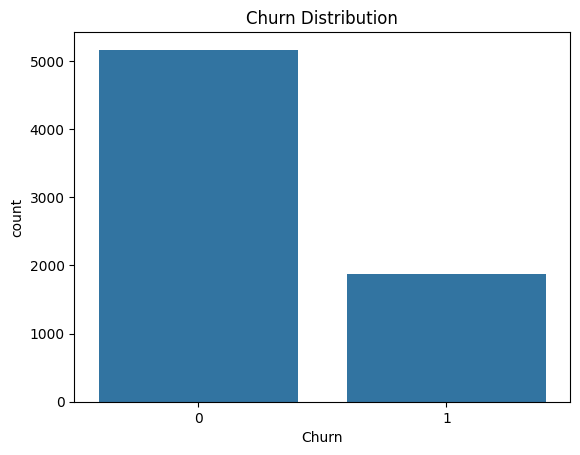

In [7]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

Insight:
- Significant number of customers churn, indicating retention issues.

### 📊 Churn by Contract Type

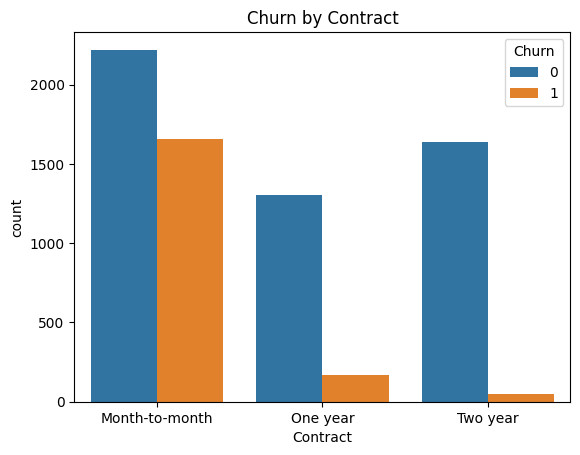

In [8]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract")
plt.show()

Insight:
- Month-to-month customers show highest churn
- Long-term contracts reduce churn

### 📊 CLV vs Churn

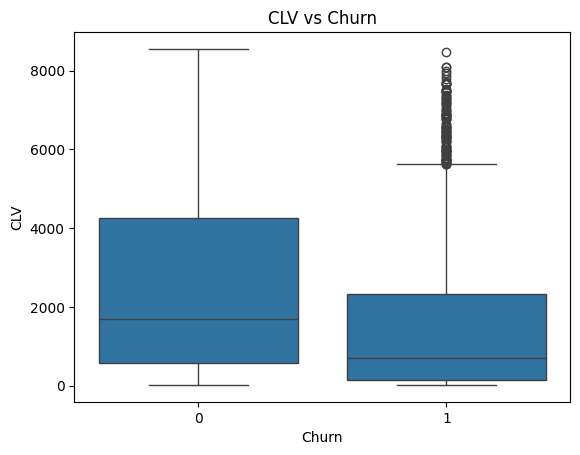

In [9]:
sns.boxplot(x="Churn", y="CLV", data=df)
plt.title("CLV vs Churn")
plt.show()

Insight:
- Low CLV customers churn more
- High-value customers are more loyal

### 📊 Engagement Score vs Churn

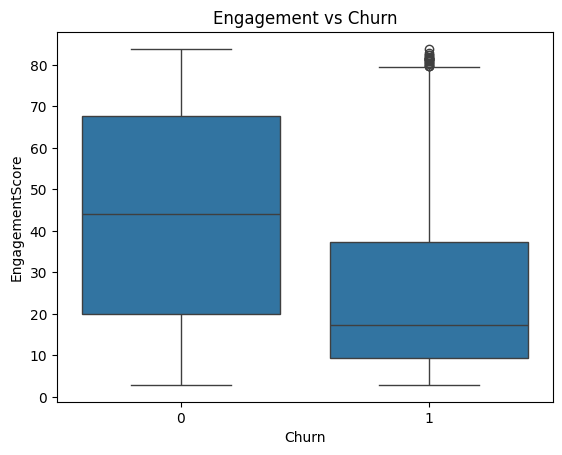

In [10]:
sns.boxplot(x="Churn", y="EngagementScore", data=df)
plt.title("Engagement vs Churn")
plt.show()

### 📊 Churn by Tenure Group

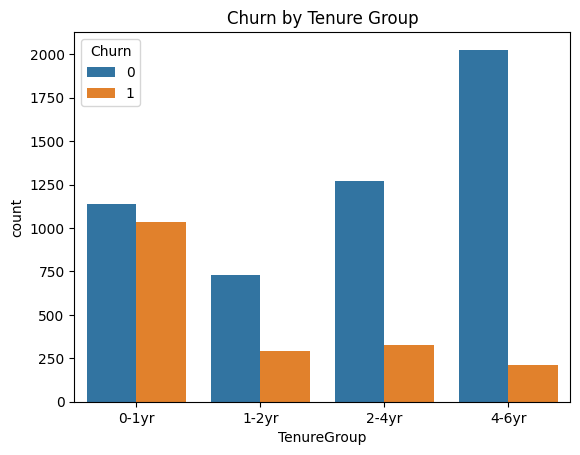

In [11]:
df["TenureGroup"] = pd.cut(df["tenure"],
                          bins=[0,12,24,48,72],
                          labels=["0-1yr","1-2yr","2-4yr","4-6yr"])

sns.countplot(x="TenureGroup", hue="Churn", data=df)
plt.title("Churn by Tenure Group")
plt.show()

### 🔥 Correlation Matrix

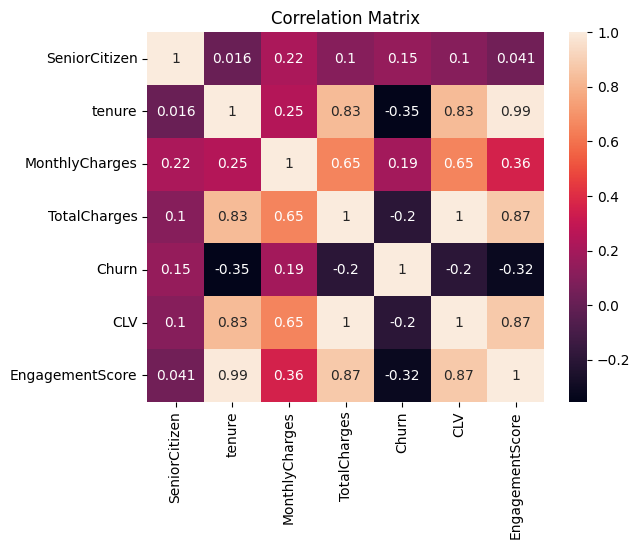

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

## 🤖 MACHINE LEARNING PIPELINE

## 🔄 Encoding Categorical Variables

In [13]:
df_encoded = pd.get_dummies(df, drop_first=True)

## 📊 Feature Selection & Split

In [14]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

## ⚙️ Feature Scaling

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 🔀 Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## 🤖 Logistic Regression Model

In [17]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## 🌳 Random Forest Model

In [18]:
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## 📊 Model Performance Comparison

In [19]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.755508
1        Random Forest  0.800284


## 📋 Classification Report

In [20]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1033
           1       0.68      0.46      0.55       374

    accuracy                           0.80      1407
   macro avg       0.75      0.69      0.71      1407
weighted avg       0.79      0.80      0.79      1407



## 🔢 Confusion Matrix

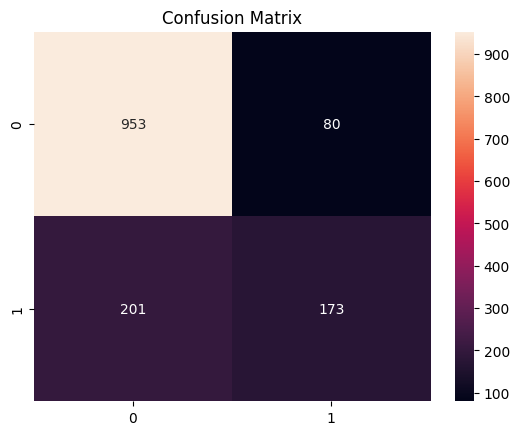

In [21]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

## 📈 ROC Curve

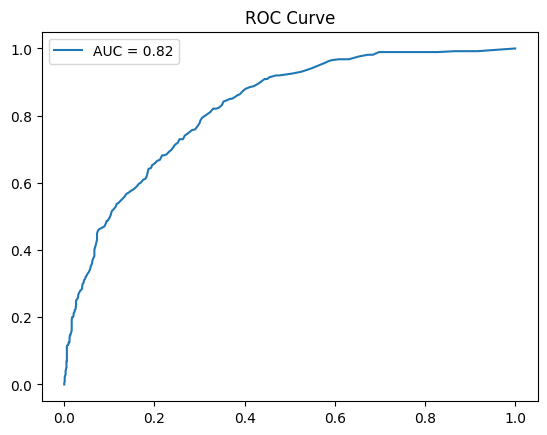

In [22]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve")
plt.show()

## 📊 Feature Importance

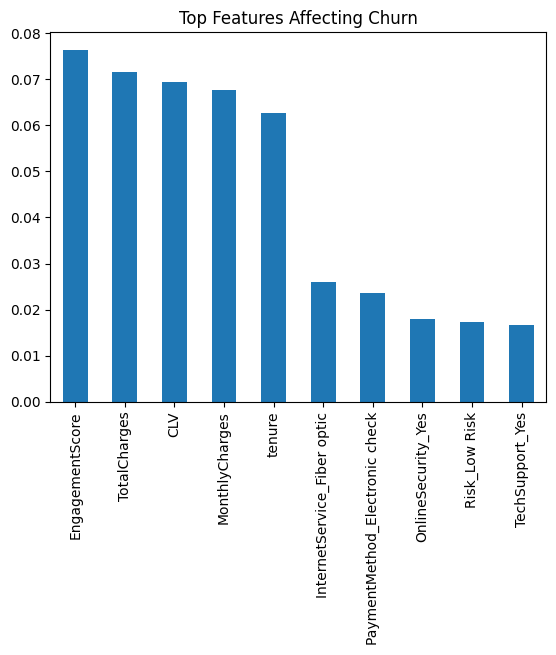

In [23]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Features Affecting Churn")
plt.show()

Insight:
- Contract type and tenure are strongest predictors
- Pricing impacts churn significantly

## 📊 Key Insights

- Month-to-month contracts have highest churn
- High monthly charges increase churn risk
- Low tenure customers are most likely to churn
- High CLV customers are more loyal
- Engagement score helps identify churn risk

## 🚀 Business Recommendations

- Promote long-term contracts
- Offer discounts to high-risk customers
- Focus on low-tenure users
- Build loyalty programs for high-value customers

## 📌 Final Takeaway

This project demonstrates how data analysis and machine learning can be used to:
- Understand customer behavior
- Predict churn risk
- Improve business decision-making